# Data Preparation / Feature Engineering

## Business objective and success criteria
This project aims to predict Remaining Useful Life (RUL) for aircraft engines so maintenance can be scheduled before failures occur. In practice, the model should help reduce unplanned downtime, avoid costly emergency repairs, and support proactive maintenance planning.

A good model should:
- predict RUL early enough to allow action before failure,
- keep prediction errors low enough that maintenance decisions are reliable,
- and generalize well to unseen engines rather than only memorizing the training set.

For this notebook, we use RMSE, MAE, and R² on a held-out validation set as the primary success criteria. Lower RMSE/MAE and higher R² indicate better predictive performance.


## Experiment: does the model rely too heavily on `cycle`?

This notebook is a copy of `step3_modeling_life_ratio.ipynb`, modified to test one
change: **`cycle` is excluded from the model's input features** (it's still kept as an
identifier column for grouping/plotting, exactly like `engine_id`, just never fed to
the model). SHAP analysis in step3 showed `cycle` was by far the largest contributor to
every prediction, which raises a leakage-like concern: the model may be mostly counting
elapsed cycles rather than learning from sensor degradation patterns. This notebook
reruns the same pipeline/tuning without `cycle` as a feature to see whether performance
holds up.

In the previous step1_eda.ipynb, we have performed some statistical analysis and draw insights on how to prepare our preliminary dataset. Including:

Train/Val split:
1. Splits dataset into training and validation before standardization, standardization should fit on train set only.
2. Must maintain local chronological order for each engine.

Data cleaning:
1. Compute life_ratio as labels
2. Removing the columns: settings1, settings2, settings3, engine_id (drop when training), T2, P2, farB, NF_dmd, PCNfR_dmd, and Nrc

Feature Scaling:
1. Sensor features are standardized using statistics computed exclusively from the training set.
2. The same transformation is applied to validation data to ensure consistency and prevent data leakage.

Feature Engineering: 
1. Compute rolling window statistics feature for sensors, grouped by engine_id.
2. Compute lags of current timestep.

In [1]:
import pandas as pd
import sys
sys.path.append("..")
from src.const import RAW_COLUMN_NAMES

columns = RAW_COLUMN_NAMES

df = pd.read_csv("../data/raw/train_FD001.txt", sep=r'\s+', header=None,
                       usecols=range(len(columns)), names=columns, engine='python')

### Train/Val split

In [2]:
from sklearn.model_selection import train_test_split
# -----------------------------
# 1. Train/Validation split by engine_id
# -----------------------------
engine_ids = df["engine_id"].unique()

train_ids, val_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_ids)].copy()
val_df   = df[df["engine_id"].isin(val_ids)].copy()

# -----------------------------
# 2. Maintain local chronological order per engine
# -----------------------------
train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
val_df   = val_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# -----------------------------
# 3. Sanity checks
# -----------------------------
assert set(train_df["engine_id"]).isdisjoint(set(val_df["engine_id"])), "Leakage detected!"
assert train_df["cycle"].is_monotonic_increasing is False or True  # per-engine ordering enforced

print("Train engines:", train_df["engine_id"].nunique())
print("Val engines:", val_df["engine_id"].nunique())
print("Split complete without engine leakage.")

Train engines: 80
Val engines: 20
Split complete without engine leakage.


In [3]:
train_df

,engine_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,522.33,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,522.70,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,522.58,2387.99,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,522.49,2387.93,8140.44,8.4018,0.03,391,2388,100.0,39.13,23.5027
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,522.27,2387.94,8136.67,8.3867,0.03,390,2388,100.0,39.18,23.4234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
16557,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
16558,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
16559,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [4]:
val_df

,engine_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0010,-0.0000,100.0,518.67,642.98,1600.49,1427.11,14.62,...,519.76,2388.28,8119.61,8.5282,0.03,395,2388,100.0,38.38,23.1238
4066,91,132,-0.0025,-0.0003,100.0,518.67,643.91,1596.94,1428.41,14.62,...,519.76,2388.30,8120.68,8.5323,0.03,397,2388,100.0,38.53,23.0055
4067,91,133,0.0012,-0.0001,100.0,518.67,644.22,1602.83,1426.55,14.62,...,519.35,2388.26,8120.11,8.5183,0.03,396,2388,100.0,38.38,23.0042
4068,91,134,0.0004,0.0006,100.0,518.67,643.70,1606.40,1430.92,14.62,...,519.43,2388.33,8119.01,8.5215,0.03,396,2388,100.0,38.25,23.0107


In [5]:
train_df.nunique()

engine_id      80
cycle         362
setting_1     156
setting_2      13
setting_3       1
T2              1
T24           305
T30          2878
T50          3893
P2              1
P15             2
P30           501
Nf             53
Nc           5911
epr             1
Ps30          155
phi           425
NRf            55
NRc          5652
BPR          1871
farB            1
htBleed        13
Nf_dmd          1
PCNfR_dmd       1
W31           119
W32          4495
dtype: int64

In [6]:
val_df.nunique()

engine_id      20
cycle         269
setting_1     133
setting_2      13
setting_3       1
T2              1
T24           276
T30          1976
T50          2409
P2              1
P15             2
P30           454
Nf             43
Nc           2729
epr             1
Ps30          144
phi           366
NRf            45
NRc          2678
BPR          1410
farB            1
htBleed        11
Nf_dmd          1
PCNfR_dmd       1
W31           108
W32          2603
dtype: int64

### Preprocess

In [7]:
# -----------------------------
# 1. Compute life_ratio
# -----------------------------
def add_rul(df, engine_col="engine_id", cycle_col="cycle"):
    """
    Adds a Remaining Useful Life (RUL) column to a CMAPSS dataframe.

    RUL = max_cycle - current_cycle, computed independently for each engine.
    """
    df = df.copy()

    df["max_cycle"] = df.groupby(engine_col)[cycle_col].transform("max")
    df["RUL"] = df["max_cycle"] - df[cycle_col]

    df.drop(columns=["max_cycle"], inplace=True)

    return df

def add_life_ratio(df, engine_col="engine_id", cycle_col="cycle", rul_col="RUL"):
    """
    Adds a normalized life_ratio column to a CMAPSS dataframe.

    life_ratio = RUL / max_cycle, always in [0, 1]. It represents the
    fraction of remaining life: close to 1 early in an engine's life and
    0 at the failure cycle. Requires RUL to already be present.
    """
    df = df.copy()

    max_cycle = df.groupby(engine_col)[cycle_col].transform("max")
    df["life_ratio"] = df[rul_col] / max_cycle

    return df

# -----------------------------
# 2. Drop unwanted columns
# -----------------------------
def clean_features(df, cols_to_drop=[]):
    df = df.copy()
    # drop feature columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

# -----------------------------
# 3. Full preprocessing pipeline
# -----------------------------
def preprocess(df, cols_to_drop=[]):
    df = add_rul(df)
    df = add_life_ratio(df)
    # RUL is dropped so it can't leak into the features; life_ratio is the target now
    df = df.drop(columns=["RUL"])
    df = clean_features(df, cols_to_drop)
    return df

In [8]:
cols_to_drop = [
    "setting_1", "setting_2", "setting_3",
    "T2", "P2", "farB", "Nf_dmd", "PCNfR_dmd", "Nc",
    "P15", "P30", "epr"
]
# cols_to_drop = []
train_df = preprocess(train_df, cols_to_drop=cols_to_drop)
val_df   = preprocess(val_df, cols_to_drop=cols_to_drop)

In [9]:
train_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,641.89,1583.84,1391.28,2388.01,46.93,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585,0.996516
1,2,2,641.82,1587.05,1393.13,2387.98,47.24,522.70,2387.98,8131.09,8.4167,392,39.06,23.4085,0.993031
2,2,3,641.55,1588.32,1398.96,2388.04,47.22,522.58,2387.99,8140.58,8.3802,391,39.11,23.4250,0.989547
3,2,4,641.68,1584.15,1396.08,2387.98,47.10,522.49,2387.93,8140.44,8.4018,391,39.13,23.5027,0.986063
4,2,5,641.73,1579.03,1402.52,2388.03,47.25,522.27,2387.94,8136.67,8.3867,390,39.18,23.4234,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,643.49,1597.98,1428.63,2388.19,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,0.020000
16557,100,197,643.54,1604.50,1433.58,2388.23,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,0.015000
16558,100,198,643.42,1602.46,1428.18,2388.24,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,0.010000
16559,100,199,643.23,1605.26,1426.53,2388.25,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,0.005000


In [10]:
val_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,1,1,641.82,1589.70,1400.60,2388.06,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.994792
1,1,2,642.15,1591.82,1403.14,2388.04,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.989583
2,1,3,642.35,1587.99,1404.20,2388.08,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.984375
3,1,4,642.35,1582.79,1401.87,2388.11,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.979167
4,1,5,642.37,1582.85,1406.22,2388.06,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.973958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,642.98,1600.49,1427.11,2388.26,48.24,519.76,2388.28,8119.61,8.5282,395,38.38,23.1238,0.029630
4066,91,132,643.91,1596.94,1428.41,2388.30,48.02,519.76,2388.30,8120.68,8.5323,397,38.53,23.0055,0.022222
4067,91,133,644.22,1602.83,1426.55,2388.29,48.07,519.35,2388.26,8120.11,8.5183,396,38.38,23.0042,0.014815
4068,91,134,643.70,1606.40,1430.92,2388.27,48.20,519.43,2388.33,8119.01,8.5215,396,38.25,23.0107,0.007407


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define sensor columns
# -----------------------------
def get_sensor_columns(df):
    return df.select_dtypes(include=["float64", "int64"]).columns.drop(
        ["life_ratio", "cycle", "engine_id"], errors="ignore"
    )

sensor_cols = get_sensor_columns(train_df)

# -----------------------------
# 2. Fit scaler ONLY on training set
# -----------------------------
scaler = StandardScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()

scaler.fit(train_df_scaled[sensor_cols])

train_df_scaled[sensor_cols] = scaler.transform(train_df_scaled[sensor_cols])
val_df_scaled[sensor_cols] = scaler.transform(val_df_scaled[sensor_cols])

# -----------------------------
# 3. Sanity check
# -----------------------------
print("Scaling complete.")
print("Train shape:", train_df_scaled.shape)
print("Val shape:", val_df_scaled.shape)

Scaling complete.
Train shape: (16561, 15)
Val shape: (4070, 15)


In [12]:
train_df_scaled

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,-1.581191,-1.092662,-1.963014,-1.221017,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436,0.996516
1,2,2,-1.721722,-0.565155,-1.756664,-1.645675,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895,0.993031
2,2,3,-2.263772,-0.356453,-1.106382,-0.796358,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524,0.989547
3,2,4,-2.002785,-1.041719,-1.427619,-1.645675,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974,0.986063
4,2,5,-1.902406,-1.883102,-0.709298,-0.937911,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,1.630956,1.230998,2.203027,1.326935,1.995779,-2.621987,2.289001,-0.322070,1.428392,2.454058,-1.823164,-2.951309,0.020000
16557,100,197,1.731335,2.302446,2.755153,1.893147,1.882880,-2.363472,1.731172,-0.378231,1.916301,1.160624,-2.879500,-1.220429,0.015000
16558,100,198,1.490424,1.967208,2.152834,2.034700,2.071044,-1.914473,2.010086,-0.145928,3.268050,3.100776,-2.101147,-3.325604,0.010000
16559,100,199,1.108982,2.427339,1.968792,2.176253,3.200030,-2.377078,1.870629,-0.235786,2.582844,1.160624,-2.935097,-2.108680,0.005000


In [13]:
train_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,16561.000000,16561.000000,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,16561.000000
mean,53.022704,109.377815,-2.197573e-14,-1.421858e-14,-4.400294e-15,-1.117482e-12,-3.514743e-15,1.054938e-13,7.276136e-12,3.933492e-15,-4.222154e-14,-1.643417e-14,-7.870416e-15,2.571186e-14,0.497585
std,29.258544,69.639875,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,0.288681
min,2.000000,1.000000,-2.946353e+00,-3.196118e+00,-2.642296e+00,-2.778098e+00,-2.595427e+00,-3.710470e+00,-3.010380e+00,-2.244824e+00,-3.042777e+00,-3.366398e+00,-3.769046e+00,-3.689657e+00,0.000000
25%,27.000000,52.000000,-6.978505e-01,-6.916913e-01,-7.249134e-01,-6.548050e-01,-7.137854e-01,-6.218996e-01,-7.790618e-01,-5.313983e-01,-7.232079e-01,-7.795285e-01,-6.556348e-01,-6.226742e-01,0.247525
50%,55.000000,104.000000,-7.549713e-02,-7.380126e-02,-1.092092e-01,-8.859342e-02,-1.116601e-01,9.922029e-02,-8.177471e-02,-1.592030e-01,-8.865916e-02,-1.328112e-01,6.712150e-02,8.308551e-02,0.497512
75%,79.000000,157.000000,6.271599e-01,6.278983e-01,6.180355e-01,6.191710e-01,6.033638e-01,7.250979e-01,6.155123e-01,2.232035e-01,6.152100e-01,5.139062e-01,7.342811e-01,7.106344e-01,0.747525
max,100.000000,362.000000,3.718851e+00,4.341812e+00,3.637440e+00,6.564392e+00,3.689256e+00,2.670761e+00,6.472724e+00,7.648730e+00,3.806617e+00,4.394210e+00,3.402920e+00,3.053235e+00,0.997238


In [14]:
val_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000
mean,45.337346,106.488698,0.033865,0.028340,0.030918,0.028196,0.028562,-0.024872,0.020403,-0.040245,0.016251,0.017348,-0.046681,-0.036393,0.497543
std,28.278657,65.659973,1.019181,1.037386,1.019407,1.023892,1.025404,1.017466,1.014766,0.859039,0.999633,1.008026,1.023694,1.038941,0.288707
min,1.000000,1.000000,-2.866050,-3.064652,-2.970226,-2.494992,-2.407263,-3.207046,-2.731466,-1.683723,-3.122762,-2.719681,-3.657853,-3.569547,0.000000
25%,19.000000,51.000000,-0.717926,-0.704838,-0.736067,-0.796358,-0.751418,-0.676324,-0.779062,-0.584879,-0.725208,-0.779529,-0.711231,-0.714619,0.246874
50%,45.000000,102.000000,-0.015269,-0.027788,-0.030573,0.052959,-0.036394,0.031190,0.057683,-0.215364,-0.048667,-0.132811,0.011525,-0.000712,0.497636
75%,77.000000,154.000000,0.707464,0.683771,0.694720,0.760724,0.678629,0.738704,0.615512,0.230224,0.684530,0.513906,0.678684,0.709703,0.747179
max,91.000000,269.000000,3.538168,4.016434,3.234778,3.450229,3.726889,2.303398,3.683575,4.438354,3.353368,3.747493,2.735760,2.941506,0.996283


### Feature Engineering (Adding rolling window and lags):
- Useful for Tree models

In [15]:
import numpy as np

WINDOW = 5
LAGS = [1, 2]

def add_time_series_features(df, sensor_cols):
    df = df.copy()
    df = df.sort_values(["engine_id", "cycle"])

    group_cols = ["engine_id"]

    # -------------------------
    # Rolling mean features
    # -------------------------
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(group_cols)[col]
              .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
        )

    # -------------------------
    # Lag features
    # -------------------------
    for col in sensor_cols:
        for lag in LAGS:
            df[f"{col}_lag{lag}"] = (
                df.groupby(group_cols)[col]
                  .shift(lag)
            )

    return df

In [16]:
def fit_feature_selector(train_df, target="life_ratio", top_k=10):
    # keep ONLY numeric columns
    numeric_df = train_df.select_dtypes(include=["number"]).copy()

    feature_cols = numeric_df.columns.drop([target, "cycle"], errors="ignore")

    corr = numeric_df[feature_cols].corrwith(numeric_df[target]).abs()
    var = numeric_df[feature_cols].var()

    score = corr * var

    score_df = (
        pd.DataFrame({
            "correlation": corr,
            "variance": var,
            "score": score
        })
        .sort_values(by="score", ascending=False)
    )

    print("\n===== Feature Scores (Top 20) =====")
    print(score_df.head(20))

    # -------------------------
    # top-k logic fix
    # -------------------------
    if top_k == -1:
        top_features = score_df.index.tolist()
        print("\nSelected ALL features")
    else:
        top_features = score_df.head(top_k).index.tolist()
        print(f"\nSelected Top {top_k} Features:")

    print(top_features)

    return top_features

In [17]:
def get_sensor_columns(df):
    exclude = {"life_ratio", "cycle", "engine_id"}

    return [
        c for c in df.select_dtypes(include=["number"]).columns
        if c not in exclude
    ]

In [18]:
def apply_feature_selection(df, selected_features, target="life_ratio"):
    if "cycle" not in selected_features:
        selected_features.append("cycle")
    if "engine_id" not in selected_features:
        selected_features.append("engine_id")
    keep_cols = [target] + selected_features
    return df[keep_cols].copy()

In [19]:
def feature_engineering_pipeline(train_df, val_df, top_k=10):
    # -------------------------
    # 1. sensor columns from TRAIN ONLY
    # -------------------------
    sensor_cols = get_sensor_columns(train_df)

    # -------------------------
    # 2. Feature engineering
    # -------------------------
    train_fe = add_time_series_features(train_df, sensor_cols)
    val_fe   = add_time_series_features(val_df, sensor_cols)
    # train_fe = train_df
    # val_fe = val_df

    # handle NaNs from lag
    train_fe = train_fe.dropna().reset_index(drop=True)
    val_fe   = val_fe.dropna().reset_index(drop=True)

    # -------------------------
    # 3. Feature selection (TRAIN ONLY)
    # -------------------------
    selected_features = fit_feature_selector(train_fe, top_k=top_k)

    print("Top selected features:", selected_features)

    # -------------------------
    # 4. Apply selection
    # -------------------------
    train_final = apply_feature_selection(train_fe, selected_features)
    val_final   = apply_feature_selection(val_fe, selected_features)

    return train_final, val_final, selected_features

In [20]:
train_final, val_final, selected_features = feature_engineering_pipeline(
    train_df_scaled,
    val_df_scaled,
    top_k=10
)


===== Feature Scores (Top 20) =====
                correlation    variance     score
engine_id          0.001105  856.267425  0.946241
Ps30               0.732691    0.999654  0.732438
T50                0.715475    0.999857  0.715373
Ps30_lag1          0.727760    0.975917  0.710233
phi                0.705401    1.000597  0.705822
T50_lag1           0.709994    0.974777  0.692086
Ps30_lag2          0.722854    0.952378  0.688430
phi_lag1           0.699790    0.976480  0.683331
BPR                0.676317    1.001738  0.677493
T50_lag2           0.704693    0.953549  0.671959
W31                0.669599    0.999716  0.669409
W32                0.669334    0.999230  0.668818
phi_lag2           0.694276    0.955295  0.663239
BPR_lag1           0.670373    0.980946  0.657599
W32_lag1           0.663764    0.980192  0.650615
W31_lag1           0.663939    0.978878  0.649915
Ps30_roll_mean     0.771527    0.836765  0.645587
htBleed            0.643505    0.999805  0.643379
T24          

In [21]:
train_final

,life_ratio,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR,T50_lag2,cycle
0,0.989547,2,-1.203012,-1.106382,-1.127747,1.582278,-1.756664,-2.294365,1.745551,-1.648369,-1.963014,3
1,0.986063,2,-1.654606,-1.427619,-1.203012,1.459824,-1.106382,-1.127747,1.582278,-1.072476,-1.756664,4
2,0.982578,2,-1.090114,-0.709298,-1.654606,1.160491,-1.427619,-1.203012,1.459824,-1.475068,-1.106382,5
3,0.979094,2,-1.842771,-1.351772,-1.090114,1.881611,-0.709298,-1.654606,1.160491,-1.653702,-1.427619,6
4,0.975610,2,-1.654606,-0.917879,-1.842771,0.983613,-1.351772,-1.090114,1.881611,-1.277771,-0.709298,7
...,...,...,...,...,...,...,...,...,...,...,...,...
16396,0.020000,100,1.995779,2.203027,2.560271,-2.621987,2.567765,2.183943,-2.322654,1.428392,2.066948,196
16397,0.015000,100,1.882880,2.755153,1.995779,-2.363472,2.203027,2.560271,-2.621987,1.916301,2.567765,197
16398,0.010000,100,2.071044,2.152834,1.882880,-1.914473,2.755153,1.995779,-2.363472,3.268050,2.203027,198
16399,0.005000,100,3.200030,1.968792,2.071044,-2.377078,2.152834,1.882880,-1.914473,2.582844,2.755153,199


In [22]:
val_final

,life_ratio,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR,T50_lag2,cycle
0,0.984375,1,-1.014848,-0.521909,-0.186926,1.364582,-0.640143,-0.262191,1.174097,-0.645889,-0.923456,3
1,0.979167,1,-1.541708,-0.781799,-1.014848,1.963247,-0.521909,-0.186926,1.364582,-1.968310,-0.640143,4
2,0.973958,1,-0.977215,-0.296597,-1.541708,1.051643,-0.781799,-1.014848,1.963247,-0.336613,-0.521909,5
3,0.968750,1,-1.428809,-1.172191,-0.977215,0.357735,-0.296597,-1.541708,1.051643,-0.832521,-0.781799,6
4,0.963542,1,-0.676153,-1.239116,-1.428809,1.228521,-1.172191,-0.977215,0.357735,-1.189788,-0.296597,7
...,...,...,...,...,...,...,...,...,...,...,...,...
4025,0.029630,91,2.635537,2.033486,2.372107,-2.254624,1.322972,1.769982,-2.200200,2.297564,2.026793,131
4026,0.022222,91,1.807615,2.178489,2.635537,-2.254624,2.033486,2.372107,-2.254624,2.406877,1.322972,132
4027,0.014815,91,1.995779,1.971023,1.807615,-2.812471,2.178489,2.635537,-2.254624,2.033613,2.033486,133
4028,0.007407,91,2.485006,2.458455,1.995779,-2.703623,1.971023,1.807615,-2.812471,2.118930,2.178489,134


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = "life_ratio"

X_train = train_final.drop(columns=[TARGET, "engine_id", "cycle"], errors="ignore")
y_train = train_final[TARGET]

X_val = val_final.drop(columns=[TARGET, "engine_id", "cycle"], errors="ignore")
y_val = val_final[TARGET]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

In [24]:
def evaluate(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{ name } Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0651
MAE : 0.0505
R2  : 0.9482

Validation Performance:
RMSE: 0.1788
MAE : 0.1391
R2  : 0.6089


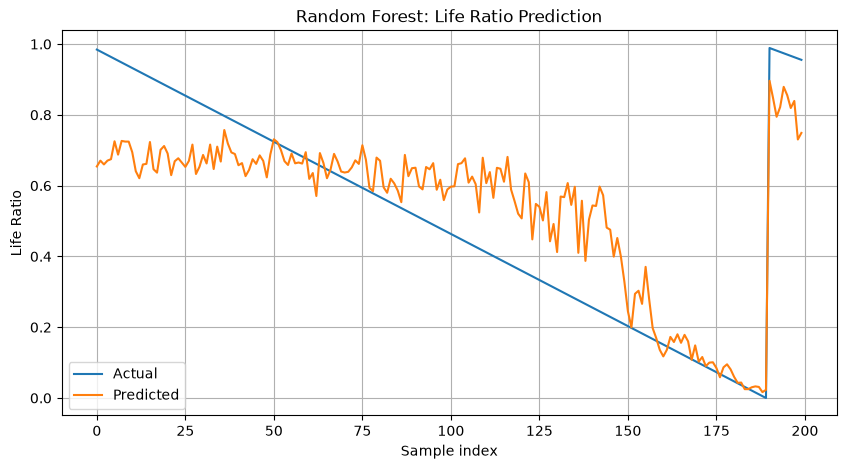

Mean validation residual (Actual - Predicted): 0.008070002004390097


In [25]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

print("Mean validation residual (Actual - Predicted):", (y_val - y_pred_val).mean())

Without `cycle`, the untuned-tuning baseline Random Forest's validation RMSE jumps from
0.0588 (with `cycle`, step3) to **0.1788**, and R² collapses from 0.9578 to **0.6089**. The
mean residual is still small, but the *spread* of errors is now far wider (see the model
comparison table and error analysis below) -- removing `cycle` costs far more accuracy than
a small bias number suggests.

### Hyperparameter tuning with Optuna

In [26]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Hyperparameter tuning random forest
besr_rf = None
best_rmse = None

def rf_objective(trial):
    global besr_rf, best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8, None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if best_rmse is None or rmse < best_rmse:
        best_rmse = rmse
        besr_rf = model

    return rmse


In [28]:
study = optuna.create_study(direction="minimize")
study.optimize(rf_objective, n_trials=100)

[I 2026-07-06 23:37:26,701] A new study created in memory with name: no-name-939227a1-d8f8-48bf-9d23-5bb4ab959a39


[I 2026-07-06 23:37:27,124] Trial 0 finished with value: 0.17771424394002833 and parameters: {'n_estimators': 196, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.17771424394002833.


[I 2026-07-06 23:37:28,692] Trial 1 finished with value: 0.1803189646427663 and parameters: {'n_estimators': 411, 'max_depth': 27, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': False}. Best is trial 0 with value: 0.17771424394002833.


[I 2026-07-06 23:37:28,945] Trial 2 finished with value: 0.1779430149938397 and parameters: {'n_estimators': 114, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 0 with value: 0.17771424394002833.


[I 2026-07-06 23:37:29,782] Trial 3 finished with value: 0.17767469927836343 and parameters: {'n_estimators': 539, 'max_depth': 86, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 3 with value: 0.17767469927836343.


[I 2026-07-06 23:37:30,164] Trial 4 finished with value: 0.17803610262638805 and parameters: {'n_estimators': 120, 'max_depth': 17, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 0.8, 'bootstrap': True}. Best is trial 3 with value: 0.17767469927836343.


[I 2026-07-06 23:37:30,950] Trial 5 finished with value: 0.1776418226825869 and parameters: {'n_estimators': 471, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 5 with value: 0.1776418226825869.


[I 2026-07-06 23:37:32,043] Trial 6 finished with value: 0.1786436029607375 and parameters: {'n_estimators': 492, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 5 with value: 0.1776418226825869.


[I 2026-07-06 23:37:33,195] Trial 7 finished with value: 0.178496742842676 and parameters: {'n_estimators': 484, 'max_depth': 86, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': False}. Best is trial 5 with value: 0.1776418226825869.


[I 2026-07-06 23:37:33,872] Trial 8 finished with value: 0.17749061386678794 and parameters: {'n_estimators': 422, 'max_depth': 24, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 8 with value: 0.17749061386678794.


[I 2026-07-06 23:37:34,403] Trial 9 finished with value: 0.17770225391450817 and parameters: {'n_estimators': 283, 'max_depth': 59, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True}. Best is trial 8 with value: 0.17749061386678794.


[I 2026-07-06 23:37:35,047] Trial 10 finished with value: 0.17837989886207425 and parameters: {'n_estimators': 316, 'max_depth': 54, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 8 with value: 0.17749061386678794.


[I 2026-07-06 23:37:38,119] Trial 11 finished with value: 0.17807621530173207 and parameters: {'n_estimators': 395, 'max_depth': 48, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 8 with value: 0.17749061386678794.


[I 2026-07-06 23:37:38,930] Trial 12 finished with value: 0.1773854793824604 and parameters: {'n_estimators': 589, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 12 with value: 0.1773854793824604.


[I 2026-07-06 23:37:39,738] Trial 13 finished with value: 0.17722092276935378 and parameters: {'n_estimators': 599, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:40,526] Trial 14 finished with value: 0.17826362646744193 and parameters: {'n_estimators': 587, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:41,301] Trial 15 finished with value: 0.17724469756494954 and parameters: {'n_estimators': 560, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:43,254] Trial 16 finished with value: 0.17813487700755756 and parameters: {'n_estimators': 548, 'max_depth': 41, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:44,130] Trial 17 finished with value: 0.1777035363514634 and parameters: {'n_estimators': 535, 'max_depth': 36, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:44,873] Trial 18 finished with value: 0.17796928515806487 and parameters: {'n_estimators': 595, 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:45,634] Trial 19 finished with value: 0.17727176125059793 and parameters: {'n_estimators': 517, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:46,351] Trial 20 finished with value: 0.177789213886829 and parameters: {'n_estimators': 446, 'max_depth': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:47,114] Trial 21 finished with value: 0.17725863330165822 and parameters: {'n_estimators': 539, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:47,934] Trial 22 finished with value: 0.17748071663565027 and parameters: {'n_estimators': 552, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:48,524] Trial 23 finished with value: 0.17772522135629987 and parameters: {'n_estimators': 359, 'max_depth': 35, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:49,245] Trial 24 finished with value: 0.17726791178465492 and parameters: {'n_estimators': 499, 'max_depth': 12, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:50,133] Trial 25 finished with value: 0.17941359648720204 and parameters: {'n_estimators': 599, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 0.8, 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:51,244] Trial 26 finished with value: 0.17811745786790859 and parameters: {'n_estimators': 558, 'max_depth': 32, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:52,711] Trial 27 finished with value: 0.1778848011514369 and parameters: {'n_estimators': 455, 'max_depth': 16, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:53,553] Trial 28 finished with value: 0.17776533383747184 and parameters: {'n_estimators': 509, 'max_depth': 42, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:54,437] Trial 29 finished with value: 0.1775668485629455 and parameters: {'n_estimators': 562, 'max_depth': 29, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 13 with value: 0.17722092276935378.


[I 2026-07-06 23:37:54,868] Trial 30 finished with value: 0.17721832827719758 and parameters: {'n_estimators': 255, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 30 with value: 0.17721832827719758.


[I 2026-07-06 23:37:55,243] Trial 31 finished with value: 0.1771150499333769 and parameters: {'n_estimators': 237, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:55,582] Trial 32 finished with value: 0.17738819596939456 and parameters: {'n_estimators': 196, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:56,262] Trial 33 finished with value: 0.17794396599606674 and parameters: {'n_estimators': 231, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:56,568] Trial 34 finished with value: 0.17774073034625962 and parameters: {'n_estimators': 147, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:56,904] Trial 35 finished with value: 0.1790789016836488 and parameters: {'n_estimators': 261, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:57,338] Trial 36 finished with value: 0.1793472314548476 and parameters: {'n_estimators': 169, 'max_depth': 28, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:58,285] Trial 37 finished with value: 0.17811876700813284 and parameters: {'n_estimators': 341, 'max_depth': 23, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:58,734] Trial 38 finished with value: 0.17780305063729188 and parameters: {'n_estimators': 235, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:37:59,939] Trial 39 finished with value: 0.19326493277621945 and parameters: {'n_estimators': 296, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': False}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:00,341] Trial 40 finished with value: 0.17758515509352701 and parameters: {'n_estimators': 199, 'max_depth': 66, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:00,749] Trial 41 finished with value: 0.17726233946643463 and parameters: {'n_estimators': 248, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:01,393] Trial 42 finished with value: 0.17764280317539083 and parameters: {'n_estimators': 375, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:01,612] Trial 43 finished with value: 0.17788786244463575 and parameters: {'n_estimators': 108, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:02,403] Trial 44 finished with value: 0.1772651471323628 and parameters: {'n_estimators': 575, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:03,352] Trial 45 finished with value: 0.17786916750846363 and parameters: {'n_estimators': 522, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:03,959] Trial 46 finished with value: 0.17717845027458473 and parameters: {'n_estimators': 418, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:04,508] Trial 47 finished with value: 0.17759706842240375 and parameters: {'n_estimators': 321, 'max_depth': 25, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:05,119] Trial 48 finished with value: 0.1775049977821724 and parameters: {'n_estimators': 396, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:05,658] Trial 49 finished with value: 0.17902175750565114 and parameters: {'n_estimators': 421, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:06,172] Trial 50 finished with value: 0.17745468765111266 and parameters: {'n_estimators': 278, 'max_depth': 72, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:06,917] Trial 51 finished with value: 0.17725885084453433 and parameters: {'n_estimators': 533, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:07,669] Trial 52 finished with value: 0.1774175392140679 and parameters: {'n_estimators': 478, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:09,930] Trial 53 finished with value: 0.1775818470897028 and parameters: {'n_estimators': 214, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:10,727] Trial 54 finished with value: 0.17726502084030657 and parameters: {'n_estimators': 574, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:11,514] Trial 55 finished with value: 0.17740311850034776 and parameters: {'n_estimators': 445, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:12,004] Trial 56 finished with value: 0.17824640730167166 and parameters: {'n_estimators': 136, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:12,272] Trial 57 finished with value: 0.17737227087989718 and parameters: {'n_estimators': 166, 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:13,010] Trial 58 finished with value: 0.1779551006693819 and parameters: {'n_estimators': 576, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:14,400] Trial 59 finished with value: 0.17759876363018456 and parameters: {'n_estimators': 537, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 0.8, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:15,274] Trial 60 finished with value: 0.17757217218948762 and parameters: {'n_estimators': 503, 'max_depth': 31, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:16,055] Trial 61 finished with value: 0.17735735329713317 and parameters: {'n_estimators': 530, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:16,838] Trial 62 finished with value: 0.1773194789084931 and parameters: {'n_estimators': 546, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:17,458] Trial 63 finished with value: 0.17902340210570927 and parameters: {'n_estimators': 467, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:18,381] Trial 64 finished with value: 0.17756197848689367 and parameters: {'n_estimators': 585, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:19,262] Trial 65 finished with value: 0.177619507253144 and parameters: {'n_estimators': 563, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:19,975] Trial 66 finished with value: 0.1774630756465381 and parameters: {'n_estimators': 517, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:20,696] Trial 67 finished with value: 0.17729557945364827 and parameters: {'n_estimators': 486, 'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:21,600] Trial 68 finished with value: 0.17756003669551465 and parameters: {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:23,778] Trial 69 finished with value: 0.19586723935571262 and parameters: {'n_estimators': 551, 'max_depth': 11, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': False}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:24,579] Trial 70 finished with value: 0.17786757163660757 and parameters: {'n_estimators': 301, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 0.8, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:25,014] Trial 71 finished with value: 0.1772635415175924 and parameters: {'n_estimators': 249, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:25,395] Trial 72 finished with value: 0.17781184100133093 and parameters: {'n_estimators': 271, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:25,755] Trial 73 finished with value: 0.17754152636619944 and parameters: {'n_estimators': 220, 'max_depth': 16, 'min_samples_split': 19, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:26,147] Trial 74 finished with value: 0.17736392951876587 and parameters: {'n_estimators': 252, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:26,485] Trial 75 finished with value: 0.1779874518058282 and parameters: {'n_estimators': 184, 'max_depth': 21, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:27,293] Trial 76 finished with value: 0.17737828139346384 and parameters: {'n_estimators': 565, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:27,828] Trial 77 finished with value: 0.17768880194861486 and parameters: {'n_estimators': 327, 'max_depth': 99, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:28,235] Trial 78 finished with value: 0.17909366745284108 and parameters: {'n_estimators': 301, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:29,043] Trial 79 finished with value: 0.17740344711419093 and parameters: {'n_estimators': 529, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:29,802] Trial 80 finished with value: 0.17858850877385482 and parameters: {'n_estimators': 359, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:30,198] Trial 81 finished with value: 0.1772517216422859 and parameters: {'n_estimators': 245, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 31 with value: 0.1771150499333769.


[I 2026-07-06 23:38:30,558] Trial 82 finished with value: 0.1771133874179246 and parameters: {'n_estimators': 225, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:30,902] Trial 83 finished with value: 0.1772864816670601 and parameters: {'n_estimators': 214, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:31,254] Trial 84 finished with value: 0.17743669269130852 and parameters: {'n_estimators': 229, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:31,568] Trial 85 finished with value: 0.1772337011268018 and parameters: {'n_estimators': 202, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:31,905] Trial 86 finished with value: 0.17790727753585917 and parameters: {'n_estimators': 190, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:32,338] Trial 87 finished with value: 0.1777140254628069 and parameters: {'n_estimators': 241, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:33,027] Trial 88 finished with value: 0.17737356195169063 and parameters: {'n_estimators': 265, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:33,229] Trial 89 finished with value: 0.17767158198734676 and parameters: {'n_estimators': 126, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:33,834] Trial 90 finished with value: 0.17794614600862443 and parameters: {'n_estimators': 202, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:34,188] Trial 91 finished with value: 0.1771999023142711 and parameters: {'n_estimators': 166, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:34,535] Trial 92 finished with value: 0.17735249897606287 and parameters: {'n_estimators': 170, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:34,828] Trial 93 finished with value: 0.17746681692959862 and parameters: {'n_estimators': 150, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:35,172] Trial 94 finished with value: 0.17714432738176825 and parameters: {'n_estimators': 208, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:35,442] Trial 95 finished with value: 0.17910145312858708 and parameters: {'n_estimators': 182, 'max_depth': 5, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:35,789] Trial 96 finished with value: 0.1771410402514173 and parameters: {'n_estimators': 204, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:36,548] Trial 97 finished with value: 0.17733951242674678 and parameters: {'n_estimators': 210, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:37,090] Trial 98 finished with value: 0.1777587326578998 and parameters: {'n_estimators': 226, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 82 with value: 0.1771133874179246.


[I 2026-07-06 23:38:37,476] Trial 99 finished with value: 0.17849870545610294 and parameters: {'n_estimators': 159, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 82 with value: 0.1771133874179246.


In [29]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.1771133874179246
Best params: {'n_estimators': 225, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}


In [30]:
y_pred_train = besr_rf.predict(X_train)
y_pred_val = besr_rf.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.1476
MAE : 0.1137
R2  : 0.7336

Validation Performance:
RMSE: 0.1771
MAE : 0.1382
R2  : 0.6161


In [31]:
import xgboost as xgb

best_xg = None
xgb_best_rmse = None


def xgb_objective(trial):
    global best_xg, xgb_best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror",
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if xgb_best_rmse is None or rmse < xgb_best_rmse:
        xgb_best_rmse = rmse
        best_xg = model

    return rmse


In [32]:
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=100)

[I 2026-07-06 23:38:37,617] A new study created in memory with name: no-name-f4c59d0f-17cb-46a1-9221-057ea30b7aaf


[I 2026-07-06 23:38:38,059] Trial 0 finished with value: 0.1839263634623623 and parameters: {'n_estimators': 452, 'max_depth': 9, 'learning_rate': 0.05145265953238557, 'subsample': 0.5004460677642124, 'colsample_bytree': 0.7346322991847406, 'min_child_weight': 9, 'gamma': 4.882452819674083, 'reg_alpha': 2.6470909449907225, 'reg_lambda': 1.6047598969147296}. Best is trial 0 with value: 0.1839263634623623.


[I 2026-07-06 23:38:38,221] Trial 1 finished with value: 0.17914094234934985 and parameters: {'n_estimators': 238, 'max_depth': 4, 'learning_rate': 0.09609297983990003, 'subsample': 0.8226703476844095, 'colsample_bytree': 0.5684326149406469, 'min_child_weight': 6, 'gamma': 0.5755715141380557, 'reg_alpha': 2.1668964596060136, 'reg_lambda': 1.7399496216190102}. Best is trial 1 with value: 0.17914094234934985.


[I 2026-07-06 23:38:38,404] Trial 2 finished with value: 0.18079917773620427 and parameters: {'n_estimators': 233, 'max_depth': 6, 'learning_rate': 0.015346960681175702, 'subsample': 0.8250195434052392, 'colsample_bytree': 0.7178141564192164, 'min_child_weight': 1, 'gamma': 2.1658921617076894, 'reg_alpha': 4.718958866437763, 'reg_lambda': 1.4007612725043224}. Best is trial 1 with value: 0.17914094234934985.


[I 2026-07-06 23:38:45,140] Trial 3 finished with value: 0.1807695104880257 and parameters: {'n_estimators': 394, 'max_depth': 9, 'learning_rate': 0.015674358242985142, 'subsample': 0.8449997858712572, 'colsample_bytree': 0.9306496600675094, 'min_child_weight': 7, 'gamma': 2.5171042502310375, 'reg_alpha': 3.985528401581254, 'reg_lambda': 2.1331303838990228}. Best is trial 1 with value: 0.17914094234934985.


[I 2026-07-06 23:38:47,175] Trial 4 finished with value: 0.17981076942047314 and parameters: {'n_estimators': 376, 'max_depth': 7, 'learning_rate': 0.1358160704700038, 'subsample': 0.8755402285166684, 'colsample_bytree': 0.991810185131269, 'min_child_weight': 1, 'gamma': 1.133654683695759, 'reg_alpha': 4.81205995028238, 'reg_lambda': 1.8048184081591074}. Best is trial 1 with value: 0.17914094234934985.


[I 2026-07-06 23:38:51,937] Trial 5 finished with value: 0.18225706883648196 and parameters: {'n_estimators': 344, 'max_depth': 4, 'learning_rate': 0.23881701387736348, 'subsample': 0.5781869740451921, 'colsample_bytree': 0.6579115480094071, 'min_child_weight': 6, 'gamma': 3.0735616020956904, 'reg_alpha': 0.6575977736406952, 'reg_lambda': 3.199418506356321}. Best is trial 1 with value: 0.17914094234934985.


[I 2026-07-06 23:38:57,303] Trial 6 finished with value: 0.18163381089731143 and parameters: {'n_estimators': 432, 'max_depth': 5, 'learning_rate': 0.035251199183399855, 'subsample': 0.7713221072346467, 'colsample_bytree': 0.7899489748222466, 'min_child_weight': 7, 'gamma': 3.330851046997757, 'reg_alpha': 2.9080404354452307, 'reg_lambda': 0.570938474440913}. Best is trial 1 with value: 0.17914094234934985.


[I 2026-07-06 23:38:57,842] Trial 7 finished with value: 0.1774098203672266 and parameters: {'n_estimators': 401, 'max_depth': 6, 'learning_rate': 0.010731868449010246, 'subsample': 0.5572033634281703, 'colsample_bytree': 0.6861638079545034, 'min_child_weight': 4, 'gamma': 0.17445433938134802, 'reg_alpha': 0.4124102486710346, 'reg_lambda': 0.7768142038713655}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:57,943] Trial 8 finished with value: 0.18161489900412947 and parameters: {'n_estimators': 111, 'max_depth': 6, 'learning_rate': 0.03541985624884248, 'subsample': 0.5028929392322704, 'colsample_bytree': 0.8811771289338963, 'min_child_weight': 3, 'gamma': 1.956701607861936, 'reg_alpha': 4.505705406798189, 'reg_lambda': 3.258720050933555}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:58,042] Trial 9 finished with value: 0.1832085444058169 and parameters: {'n_estimators': 114, 'max_depth': 3, 'learning_rate': 0.017199554588271253, 'subsample': 0.597264895759356, 'colsample_bytree': 0.898949935766348, 'min_child_weight': 8, 'gamma': 1.3451696929500185, 'reg_alpha': 2.312161319833892, 'reg_lambda': 0.7379154091529888}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:58,303] Trial 10 finished with value: 0.18153424159730241 and parameters: {'n_estimators': 492, 'max_depth': 10, 'learning_rate': 0.010233306441301156, 'subsample': 0.9771690731765392, 'colsample_bytree': 0.5262707057234126, 'min_child_weight': 4, 'gamma': 4.633875455196112, 'reg_alpha': 0.15603544873643244, 'reg_lambda': 4.842255410467965}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:58,610] Trial 11 finished with value: 0.17786139164031037 and parameters: {'n_estimators': 283, 'max_depth': 3, 'learning_rate': 0.08645108409992251, 'subsample': 0.7091047495917845, 'colsample_bytree': 0.5561143540566985, 'min_child_weight': 5, 'gamma': 0.011801213075159911, 'reg_alpha': 1.3122546825658634, 'reg_lambda': 0.7632189063925083}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:58,876] Trial 12 finished with value: 0.18045335970189344 and parameters: {'n_estimators': 298, 'max_depth': 3, 'learning_rate': 0.27582325937632474, 'subsample': 0.6770285402548111, 'colsample_bytree': 0.6136487870038608, 'min_child_weight': 4, 'gamma': 0.005343048468214595, 'reg_alpha': 1.2562309460215817, 'reg_lambda': 0.1734624070837677}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:59,277] Trial 13 finished with value: 0.178695168547693 and parameters: {'n_estimators': 284, 'max_depth': 7, 'learning_rate': 0.07243831245149675, 'subsample': 0.6993793428992161, 'colsample_bytree': 0.5083115323925486, 'min_child_weight': 3, 'gamma': 0.03835072588660182, 'reg_alpha': 1.3073501473360194, 'reg_lambda': 0.030273054509093233}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:59,377] Trial 14 finished with value: 0.17995193159382988 and parameters: {'n_estimators': 195, 'max_depth': 5, 'learning_rate': 0.1495479029853027, 'subsample': 0.6675782670871155, 'colsample_bytree': 0.6514762881313917, 'min_child_weight': 5, 'gamma': 0.8537798841903775, 'reg_alpha': 1.2879205401731428, 'reg_lambda': 1.0969522646192855}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:59,624] Trial 15 finished with value: 0.17885957567731195 and parameters: {'n_estimators': 330, 'max_depth': 8, 'learning_rate': 0.02825349066432487, 'subsample': 0.6164090531670987, 'colsample_bytree': 0.7908566317935296, 'min_child_weight': 10, 'gamma': 0.6581404488838458, 'reg_alpha': 0.029487783940347345, 'reg_lambda': 2.493026570832812}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:59,755] Trial 16 finished with value: 0.17988245312370557 and parameters: {'n_estimators': 184, 'max_depth': 4, 'learning_rate': 0.060113531656095946, 'subsample': 0.7313868054278179, 'colsample_bytree': 0.5892350675002508, 'min_child_weight': 3, 'gamma': 1.559784751493013, 'reg_alpha': 0.9067581501618037, 'reg_lambda': 0.8410069521738266}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:38:59,992] Trial 17 finished with value: 0.1782598032857642 and parameters: {'n_estimators': 407, 'max_depth': 6, 'learning_rate': 0.025578033709854352, 'subsample': 0.9490515417946646, 'colsample_bytree': 0.6940088162502077, 'min_child_weight': 5, 'gamma': 0.3747426336868786, 'reg_alpha': 1.823267658224564, 'reg_lambda': 2.492928935661648}. Best is trial 7 with value: 0.1774098203672266.


[I 2026-07-06 23:39:00,665] Trial 18 finished with value: 0.1771482820997016 and parameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.010895868864320837, 'subsample': 0.5593834796951569, 'colsample_bytree': 0.5602727791263215, 'min_child_weight': 2, 'gamma': 0.08380581743429316, 'reg_alpha': 0.3430336804183681, 'reg_lambda': 0.4448462422169739}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:01,196] Trial 19 finished with value: 0.1795711341106475 and parameters: {'n_estimators': 496, 'max_depth': 5, 'learning_rate': 0.011003718060679766, 'subsample': 0.5549656263581233, 'colsample_bytree': 0.7803014493094469, 'min_child_weight': 2, 'gamma': 0.9916401322160112, 'reg_alpha': 0.4850919313147735, 'reg_lambda': 4.781495080418258}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:01,496] Trial 20 finished with value: 0.1801047703227295 and parameters: {'n_estimators': 451, 'max_depth': 7, 'learning_rate': 0.023083505168789754, 'subsample': 0.6413780976491907, 'colsample_bytree': 0.6317435987932356, 'min_child_weight': 2, 'gamma': 1.564567750322575, 'reg_alpha': 0.4165037968769063, 'reg_lambda': 0.3628873003374464}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:01,802] Trial 21 finished with value: 0.17891999618988183 and parameters: {'n_estimators': 362, 'max_depth': 3, 'learning_rate': 0.011770785516214997, 'subsample': 0.5349973210130823, 'colsample_bytree': 0.5583742850569572, 'min_child_weight': 4, 'gamma': 0.2853083278336867, 'reg_alpha': 0.9112914760318349, 'reg_lambda': 1.1425517936489515}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:02,148] Trial 22 finished with value: 0.17724915734802074 and parameters: {'n_estimators': 297, 'max_depth': 5, 'learning_rate': 0.019109700214431, 'subsample': 0.7354476353963659, 'colsample_bytree': 0.548027060286043, 'min_child_weight': 5, 'gamma': 0.02896844108866295, 'reg_alpha': 1.7361672872390617, 'reg_lambda': 0.6065734998943975}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:02,484] Trial 23 finished with value: 0.17920585382706736 and parameters: {'n_estimators': 420, 'max_depth': 5, 'learning_rate': 0.018109072978211026, 'subsample': 0.6406557169386533, 'colsample_bytree': 0.6035937403132404, 'min_child_weight': 2, 'gamma': 0.5081487224121277, 'reg_alpha': 3.482853537570165, 'reg_lambda': 0.4476501962223244}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:02,868] Trial 24 finished with value: 0.17926571689008683 and parameters: {'n_estimators': 453, 'max_depth': 6, 'learning_rate': 0.012487386694551296, 'subsample': 0.7792438834723637, 'colsample_bytree': 0.505117449766378, 'min_child_weight': 4, 'gamma': 0.8561992862794257, 'reg_alpha': 1.7985943222262017, 'reg_lambda': 1.114961212528426}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:03,178] Trial 25 finished with value: 0.1788423518308207 and parameters: {'n_estimators': 307, 'max_depth': 4, 'learning_rate': 0.01859341046519105, 'subsample': 0.5546229520608591, 'colsample_bytree': 0.6699296184991769, 'min_child_weight': 6, 'gamma': 0.4174863087752313, 'reg_alpha': 1.7334601564360002, 'reg_lambda': 0.08131928341955891}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:03,481] Trial 26 finished with value: 0.17934817431540948 and parameters: {'n_estimators': 474, 'max_depth': 5, 'learning_rate': 0.01456569481197431, 'subsample': 0.9059901933643123, 'colsample_bytree': 0.5476318204277475, 'min_child_weight': 3, 'gamma': 1.2507134870511232, 'reg_alpha': 0.7951984375988885, 'reg_lambda': 1.3158894806208223}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:03,838] Trial 27 finished with value: 0.17793702018649502 and parameters: {'n_estimators': 381, 'max_depth': 7, 'learning_rate': 0.021394817648115624, 'subsample': 0.7472229881747778, 'colsample_bytree': 0.5947195371026417, 'min_child_weight': 2, 'gamma': 0.2604314438454988, 'reg_alpha': 0.2999795088547068, 'reg_lambda': 0.8655283805916448}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:04,167] Trial 28 finished with value: 0.17999681449471597 and parameters: {'n_estimators': 330, 'max_depth': 6, 'learning_rate': 0.010079437934731853, 'subsample': 0.5770052189753316, 'colsample_bytree': 0.751071683185585, 'min_child_weight': 5, 'gamma': 0.8174230097012795, 'reg_alpha': 3.4795189007644964, 'reg_lambda': 0.4839970049342776}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:04,439] Trial 29 finished with value: 0.183068358445139 and parameters: {'n_estimators': 438, 'max_depth': 5, 'learning_rate': 0.039282832614607834, 'subsample': 0.5015698531506513, 'colsample_bytree': 0.6969143276891987, 'min_child_weight': 1, 'gamma': 4.606565662299619, 'reg_alpha': 2.7038743895961463, 'reg_lambda': 1.4919566798169352}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:04,774] Trial 30 finished with value: 0.1803602519723497 and parameters: {'n_estimators': 466, 'max_depth': 8, 'learning_rate': 0.04503811594251099, 'subsample': 0.6181585194400707, 'colsample_bytree': 0.7491485763457639, 'min_child_weight': 7, 'gamma': 1.740943774497718, 'reg_alpha': 2.2489611802367193, 'reg_lambda': 1.972794980610985}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:05,098] Trial 31 finished with value: 0.17813164201941525 and parameters: {'n_estimators': 255, 'max_depth': 4, 'learning_rate': 0.01303115720811972, 'subsample': 0.706763834810098, 'colsample_bytree': 0.539049649525533, 'min_child_weight': 5, 'gamma': 0.13583976961493616, 'reg_alpha': 1.5255049334687736, 'reg_lambda': 0.8203880526213856}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:05,242] Trial 32 finished with value: 0.17937929810451536 and parameters: {'n_estimators': 271, 'max_depth': 3, 'learning_rate': 0.0912859036136972, 'subsample': 0.7814275617519972, 'colsample_bytree': 0.5746553524690311, 'min_child_weight': 6, 'gamma': 0.5273519830088047, 'reg_alpha': 1.0470015319286918, 'reg_lambda': 0.36686008705008466}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:05,494] Trial 33 finished with value: 0.17968967104629774 and parameters: {'n_estimators': 220, 'max_depth': 4, 'learning_rate': 0.16703850880046306, 'subsample': 0.6551832945252217, 'colsample_bytree': 0.5590823147915719, 'min_child_weight': 4, 'gamma': 0.0014744640659500978, 'reg_alpha': 0.5968043099452657, 'reg_lambda': 1.009620907152485}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:05,640] Trial 34 finished with value: 0.1788642391749427 and parameters: {'n_estimators': 147, 'max_depth': 6, 'learning_rate': 0.029324547727034096, 'subsample': 0.8113333290218031, 'colsample_bytree': 0.8415751255864413, 'min_child_weight': 5, 'gamma': 0.5912671744213102, 'reg_alpha': 2.067281449882613, 'reg_lambda': 1.7035452270987566}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:05,804] Trial 35 finished with value: 0.17848735933353752 and parameters: {'n_estimators': 252, 'max_depth': 8, 'learning_rate': 0.11022546037440445, 'subsample': 0.7037154612046227, 'colsample_bytree': 0.6313631254751194, 'min_child_weight': 6, 'gamma': 0.2859077222764207, 'reg_alpha': 1.1106338707579675, 'reg_lambda': 1.3809056467796337}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:06,089] Trial 36 finished with value: 0.1800192333087217 and parameters: {'n_estimators': 353, 'max_depth': 4, 'learning_rate': 0.014206289835681047, 'subsample': 0.5377196576277797, 'colsample_bytree': 0.5013923770456806, 'min_child_weight': 8, 'gamma': 1.1106307550873744, 'reg_alpha': 1.5666978993609098, 'reg_lambda': 0.6855967086274207}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:06,360] Trial 37 finished with value: 0.17875831914862636 and parameters: {'n_estimators': 316, 'max_depth': 5, 'learning_rate': 0.020577627722222967, 'subsample': 0.7452628116020775, 'colsample_bytree': 0.6251943118718652, 'min_child_weight': 1, 'gamma': 0.7010855039244102, 'reg_alpha': 0.6742059129370118, 'reg_lambda': 0.29047462309941335}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:06,593] Trial 38 finished with value: 0.17787283758676284 and parameters: {'n_estimators': 393, 'max_depth': 7, 'learning_rate': 0.05293602921531869, 'subsample': 0.8482735544611046, 'colsample_bytree': 0.5766580552041546, 'min_child_weight': 3, 'gamma': 0.2779291215270844, 'reg_alpha': 0.020063334001144018, 'reg_lambda': 0.5943294995982493}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:06,908] Trial 39 finished with value: 0.18205791976166927 and parameters: {'n_estimators': 223, 'max_depth': 6, 'learning_rate': 0.01544035598076529, 'subsample': 0.6048466220729373, 'colsample_bytree': 0.7162537148270282, 'min_child_weight': 5, 'gamma': 3.4735638818604864, 'reg_alpha': 2.563435481787356, 'reg_lambda': 0.0052401372030682625}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:07,041] Trial 40 finished with value: 0.18120098093735745 and parameters: {'n_estimators': 283, 'max_depth': 3, 'learning_rate': 0.21329577026239183, 'subsample': 0.8049963809518341, 'colsample_bytree': 0.5280535001705451, 'min_child_weight': 6, 'gamma': 2.599617857921712, 'reg_alpha': 0.3438334117720432, 'reg_lambda': 2.1109623121092183}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:07,464] Trial 41 finished with value: 0.17765285163021846 and parameters: {'n_estimators': 396, 'max_depth': 7, 'learning_rate': 0.06305596068445013, 'subsample': 0.8435692474575182, 'colsample_bytree': 0.5768380632770547, 'min_child_weight': 3, 'gamma': 0.2558412857952326, 'reg_alpha': 0.016232918161475603, 'reg_lambda': 0.6059599532491855}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:07,777] Trial 42 finished with value: 0.1782280186589155 and parameters: {'n_estimators': 372, 'max_depth': 8, 'learning_rate': 0.0746123202040377, 'subsample': 0.8916606105288497, 'colsample_bytree': 0.5363837756283617, 'min_child_weight': 4, 'gamma': 0.04716443257458328, 'reg_alpha': 0.23649940288393534, 'reg_lambda': 0.6532385015397473}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:07,978] Trial 43 finished with value: 0.17837446931886755 and parameters: {'n_estimators': 418, 'max_depth': 9, 'learning_rate': 0.11892557226883065, 'subsample': 0.8693647818876656, 'colsample_bytree': 0.657496460806938, 'min_child_weight': 3, 'gamma': 0.503786413335896, 'reg_alpha': 0.6264709461123902, 'reg_lambda': 1.309271734883605}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:08,158] Trial 44 finished with value: 0.17796649200300443 and parameters: {'n_estimators': 345, 'max_depth': 7, 'learning_rate': 0.07396417949587913, 'subsample': 0.996949482908157, 'colsample_bytree': 0.5738292083757089, 'min_child_weight': 2, 'gamma': 0.22667717202909782, 'reg_alpha': 1.4409918620071516, 'reg_lambda': 0.9565462709925816}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:08,363] Trial 45 finished with value: 0.17891700846995043 and parameters: {'n_estimators': 395, 'max_depth': 6, 'learning_rate': 0.05640024464511607, 'subsample': 0.9278348444845154, 'colsample_bytree': 0.9592245556691141, 'min_child_weight': 4, 'gamma': 0.9731744090638657, 'reg_alpha': 0.01005323293731588, 'reg_lambda': 0.2437408749216345}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:08,925] Trial 46 finished with value: 0.1788321098862926 and parameters: {'n_estimators': 476, 'max_depth': 5, 'learning_rate': 0.09025492622786127, 'subsample': 0.8455173284823027, 'colsample_bytree': 0.6083490929984341, 'min_child_weight': 3, 'gamma': 0.6864337303875031, 'reg_alpha': 2.012257884068015, 'reg_lambda': 4.462953808960145}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:09,100] Trial 47 finished with value: 0.17920007120811474 and parameters: {'n_estimators': 325, 'max_depth': 7, 'learning_rate': 0.18657558077052666, 'subsample': 0.5799468599150884, 'colsample_bytree': 0.5278502963644994, 'min_child_weight': 4, 'gamma': 0.43392079217576274, 'reg_alpha': 1.0180920365565953, 'reg_lambda': 0.6152148703687829}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:09,378] Trial 48 finished with value: 0.1776582584891159 and parameters: {'n_estimators': 293, 'max_depth': 5, 'learning_rate': 0.03143222706909486, 'subsample': 0.7269889983270803, 'colsample_bytree': 0.681573300028063, 'min_child_weight': 7, 'gamma': 0.14097592173883594, 'reg_alpha': 1.1879795332343548, 'reg_lambda': 1.5849628158497522}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:09,547] Trial 49 finished with value: 0.179891515298161 and parameters: {'n_estimators': 197, 'max_depth': 5, 'learning_rate': 0.035684216256124106, 'subsample': 0.6884831384012564, 'colsample_bytree': 0.6871262380418945, 'min_child_weight': 8, 'gamma': 1.3382264222357856, 'reg_alpha': 0.7044566579549181, 'reg_lambda': 2.5201149731228942}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:09,766] Trial 50 finished with value: 0.1787738445138084 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.03037378842951124, 'subsample': 0.7268192210873784, 'colsample_bytree': 0.6394819434397419, 'min_child_weight': 9, 'gamma': 0.7318297836040419, 'reg_alpha': 0.43194384919916806, 'reg_lambda': 1.8296286404694193}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:10,105] Trial 51 finished with value: 0.1777285529563286 and parameters: {'n_estimators': 267, 'max_depth': 5, 'learning_rate': 0.044059612777453745, 'subsample': 0.7566351332060707, 'colsample_bytree': 0.6720546042638224, 'min_child_weight': 7, 'gamma': 0.004034528418652816, 'reg_alpha': 1.184920710679358, 'reg_lambda': 1.5661268956225465}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:10,331] Trial 52 finished with value: 0.17769284557420556 and parameters: {'n_estimators': 261, 'max_depth': 5, 'learning_rate': 0.04132464302565899, 'subsample': 0.7663055479484173, 'colsample_bytree': 0.7280323959961021, 'min_child_weight': 7, 'gamma': 0.16799442379808807, 'reg_alpha': 1.192576024667301, 'reg_lambda': 1.5168822025109385}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:10,492] Trial 53 finished with value: 0.17744269181328906 and parameters: {'n_estimators': 236, 'max_depth': 6, 'learning_rate': 0.06395453404228232, 'subsample': 0.7821086908610788, 'colsample_bytree': 0.8106254610884035, 'min_child_weight': 8, 'gamma': 0.20015790304445052, 'reg_alpha': 0.19523002777853943, 'reg_lambda': 1.2507654432059465}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:10,641] Trial 54 finished with value: 0.1781178844732264 and parameters: {'n_estimators': 241, 'max_depth': 6, 'learning_rate': 0.061296223904036294, 'subsample': 0.8038168261389965, 'colsample_bytree': 0.8539780562332276, 'min_child_weight': 9, 'gamma': 0.3886005948643852, 'reg_alpha': 0.24699348491320514, 'reg_lambda': 1.1409667620072121}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:10,856] Trial 55 finished with value: 0.1793487297296528 and parameters: {'n_estimators': 167, 'max_depth': 6, 'learning_rate': 0.017056316026383394, 'subsample': 0.8263005446853577, 'colsample_bytree': 0.8139865201886185, 'min_child_weight': 10, 'gamma': 1.0527077219925824, 'reg_alpha': 0.8432953804971017, 'reg_lambda': 1.2808042267552455}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:11,162] Trial 56 finished with value: 0.1775889905937149 and parameters: {'n_estimators': 206, 'max_depth': 6, 'learning_rate': 0.025874827276056583, 'subsample': 0.7265768913108934, 'colsample_bytree': 0.9132542284500366, 'min_child_weight': 8, 'gamma': 0.21778748714625412, 'reg_alpha': 0.4873542451989421, 'reg_lambda': 0.9365226631604542}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:11,334] Trial 57 finished with value: 0.17873663831864453 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.025351227788812755, 'subsample': 0.524333833608348, 'colsample_bytree': 0.9210989299968024, 'min_child_weight': 9, 'gamma': 0.6049539064479659, 'reg_alpha': 0.16839033695952996, 'reg_lambda': 0.8325325466674095}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:11,593] Trial 58 finished with value: 0.17988968557901175 and parameters: {'n_estimators': 199, 'max_depth': 7, 'learning_rate': 0.011567136374762272, 'subsample': 0.7904191844198298, 'colsample_bytree': 0.9997098432233578, 'min_child_weight': 8, 'gamma': 0.8723499172052208, 'reg_alpha': 0.4889875977855204, 'reg_lambda': 0.5000176925986872}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:13,692] Trial 59 finished with value: 0.17903725737717124 and parameters: {'n_estimators': 218, 'max_depth': 6, 'learning_rate': 0.013646942791856558, 'subsample': 0.8688204485567386, 'colsample_bytree': 0.9599582350796191, 'min_child_weight': 2, 'gamma': 0.37105471003845925, 'reg_alpha': 4.562937505528068, 'reg_lambda': 0.9824149096267363}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:13,953] Trial 60 finished with value: 0.17769164284195352 and parameters: {'n_estimators': 499, 'max_depth': 7, 'learning_rate': 0.066324797386269, 'subsample': 0.823363225028038, 'colsample_bytree': 0.8824120398602718, 'min_child_weight': 1, 'gamma': 0.19325697747761147, 'reg_alpha': 0.14859061389987044, 'reg_lambda': 0.18259534396206367}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:14,153] Trial 61 finished with value: 0.17750562381834228 and parameters: {'n_estimators': 165, 'max_depth': 6, 'learning_rate': 0.03295185067100833, 'subsample': 0.7287658642728176, 'colsample_bytree': 0.7824541675964772, 'min_child_weight': 8, 'gamma': 0.15761382966826587, 'reg_alpha': 0.47657356973251125, 'reg_lambda': 1.198043739173297}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:14,371] Trial 62 finished with value: 0.17849419675340666 and parameters: {'n_estimators': 175, 'max_depth': 6, 'learning_rate': 0.02451909950241736, 'subsample': 0.6608238281717979, 'colsample_bytree': 0.8133710967423239, 'min_child_weight': 8, 'gamma': 0.45246195694686536, 'reg_alpha': 0.4894359443535811, 'reg_lambda': 1.2553037625428927}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:14,653] Trial 63 finished with value: 0.1786002151350604 and parameters: {'n_estimators': 166, 'max_depth': 6, 'learning_rate': 0.020400279331039193, 'subsample': 0.689936591682926, 'colsample_bytree': 0.7688710517645487, 'min_child_weight': 9, 'gamma': 0.2235608205362044, 'reg_alpha': 3.2589155164748322, 'reg_lambda': 0.7587753601191264}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:14,744] Trial 64 finished with value: 0.1787178987853376 and parameters: {'n_estimators': 101, 'max_depth': 7, 'learning_rate': 0.0494142257925038, 'subsample': 0.7412905887025961, 'colsample_bytree': 0.8559805003900333, 'min_child_weight': 8, 'gamma': 0.5954285124617766, 'reg_alpha': 0.8247792891174865, 'reg_lambda': 0.4596406865010833}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:15,048] Trial 65 finished with value: 0.17793601613776952 and parameters: {'n_estimators': 207, 'max_depth': 6, 'learning_rate': 0.016365835081762977, 'subsample': 0.7222252344746292, 'colsample_bytree': 0.8087981205831558, 'min_child_weight': 10, 'gamma': 0.34525864200159456, 'reg_alpha': 0.38625920031158884, 'reg_lambda': 1.0469515850068378}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:15,267] Trial 66 finished with value: 0.17806176121580902 and parameters: {'n_estimators': 238, 'max_depth': 5, 'learning_rate': 0.034875146046881425, 'subsample': 0.637874112219932, 'colsample_bytree': 0.911256931217845, 'min_child_weight': 3, 'gamma': 0.10868746045548086, 'reg_alpha': 4.113182633343877, 'reg_lambda': 0.856804684406575}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:15,474] Trial 67 finished with value: 0.18847134123615508 and parameters: {'n_estimators': 130, 'max_depth': 8, 'learning_rate': 0.010090953691822524, 'subsample': 0.676843511620788, 'colsample_bytree': 0.5916985897655687, 'min_child_weight': 7, 'gamma': 0.8248553826422247, 'reg_alpha': 0.12083732876851494, 'reg_lambda': 4.113674938938063}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:15,761] Trial 68 finished with value: 0.18164303707815943 and parameters: {'n_estimators': 447, 'max_depth': 4, 'learning_rate': 0.0120263035065007, 'subsample': 0.7902285763746378, 'colsample_bytree': 0.9436793717938621, 'min_child_weight': 3, 'gamma': 4.053851697420705, 'reg_alpha': 0.5744177198520717, 'reg_lambda': 1.171182003451944}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:15,914] Trial 69 finished with value: 0.1784891842218509 and parameters: {'n_estimators': 154, 'max_depth': 6, 'learning_rate': 0.02688977484591766, 'subsample': 0.5940196904751996, 'colsample_bytree': 0.8835628308863551, 'min_child_weight': 9, 'gamma': 0.464993752216642, 'reg_alpha': 0.3004545255428426, 'reg_lambda': 0.4046578024705623}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:16,205] Trial 70 finished with value: 0.17721366467217267 and parameters: {'n_estimators': 188, 'max_depth': 7, 'learning_rate': 0.02235465943712985, 'subsample': 0.7598138733475734, 'colsample_bytree': 0.8290003974979593, 'min_child_weight': 8, 'gamma': 0.10848034000380645, 'reg_alpha': 0.716665835291833, 'reg_lambda': 0.7213729381135439}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:16,561] Trial 71 finished with value: 0.17722202506168697 and parameters: {'n_estimators': 181, 'max_depth': 7, 'learning_rate': 0.01925564223184128, 'subsample': 0.7160870491908454, 'colsample_bytree': 0.8308456569177344, 'min_child_weight': 8, 'gamma': 0.12011469241667172, 'reg_alpha': 0.6991033830303932, 'reg_lambda': 0.7108900845299522}. Best is trial 18 with value: 0.1771482820997016.


[I 2026-07-06 23:39:16,902] Trial 72 finished with value: 0.1771069334372597 and parameters: {'n_estimators': 178, 'max_depth': 7, 'learning_rate': 0.022551685214988036, 'subsample': 0.7613073918292607, 'colsample_bytree': 0.8260092707575506, 'min_child_weight': 8, 'gamma': 0.022701860115645442, 'reg_alpha': 0.7560628391519049, 'reg_lambda': 1.0074545666628745}. Best is trial 72 with value: 0.1771069334372597.


[I 2026-07-06 23:39:17,520] Trial 73 finished with value: 0.17704861165379884 and parameters: {'n_estimators': 181, 'max_depth': 7, 'learning_rate': 0.01915673834725408, 'subsample': 0.7644906361088593, 'colsample_bytree': 0.8400923343420882, 'min_child_weight': 8, 'gamma': 0.11837137243182876, 'reg_alpha': 0.9011405107809004, 'reg_lambda': 1.3885032973355895}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:17,951] Trial 74 finished with value: 0.17708818640195056 and parameters: {'n_estimators': 180, 'max_depth': 8, 'learning_rate': 0.018857020739188157, 'subsample': 0.7583503306970526, 'colsample_bytree': 0.8314917412072995, 'min_child_weight': 7, 'gamma': 0.0017305500776502517, 'reg_alpha': 0.9416593020000156, 'reg_lambda': 0.7264180927802621}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:18,297] Trial 75 finished with value: 0.17713626343966946 and parameters: {'n_estimators': 145, 'max_depth': 8, 'learning_rate': 0.02308032582285227, 'subsample': 0.7579393044258661, 'colsample_bytree': 0.8334220061136757, 'min_child_weight': 7, 'gamma': 0.03246990584311521, 'reg_alpha': 0.9396951184585535, 'reg_lambda': 0.7028337278594889}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:18,977] Trial 76 finished with value: 0.17732777404761002 and parameters: {'n_estimators': 182, 'max_depth': 9, 'learning_rate': 0.01886644637347553, 'subsample': 0.7681309549075613, 'colsample_bytree': 0.8343551212035037, 'min_child_weight': 7, 'gamma': 0.011049932518545757, 'reg_alpha': 0.970786817930791, 'reg_lambda': 0.711232781729858}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:19,286] Trial 77 finished with value: 0.1772781555823775 and parameters: {'n_estimators': 132, 'max_depth': 8, 'learning_rate': 0.022474756589867004, 'subsample': 0.755764604946343, 'colsample_bytree': 0.8291300888840331, 'min_child_weight': 7, 'gamma': 0.017290804610255388, 'reg_alpha': 1.38653265676779, 'reg_lambda': 0.23595385582899772}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:19,527] Trial 78 finished with value: 0.1782132752395658 and parameters: {'n_estimators': 186, 'max_depth': 8, 'learning_rate': 0.019134156526482413, 'subsample': 0.758503270402344, 'colsample_bytree': 0.8642354091821657, 'min_child_weight': 6, 'gamma': 0.3782471622905571, 'reg_alpha': 1.6300853318932427, 'reg_lambda': 0.0997946625258408}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:19,710] Trial 79 finished with value: 0.17795398269544996 and parameters: {'n_estimators': 143, 'max_depth': 9, 'learning_rate': 0.023463554723211506, 'subsample': 0.712400606032883, 'colsample_bytree': 0.7989731042829643, 'min_child_weight': 9, 'gamma': 0.3198315103556085, 'reg_alpha': 0.7428653682171318, 'reg_lambda': 0.3541660232249518}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:19,886] Trial 80 finished with value: 0.18150767053213715 and parameters: {'n_estimators': 119, 'max_depth': 8, 'learning_rate': 0.0156249553701138, 'subsample': 0.7451963541739944, 'colsample_bytree': 0.7671062610447605, 'min_child_weight': 8, 'gamma': 0.5723943436345951, 'reg_alpha': 0.9100424474798235, 'reg_lambda': 0.5302110328777919}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:20,199] Trial 81 finished with value: 0.17728427124604942 and parameters: {'n_estimators': 156, 'max_depth': 8, 'learning_rate': 0.021416370038137882, 'subsample': 0.7556323148027243, 'colsample_bytree': 0.8290653248011103, 'min_child_weight': 7, 'gamma': 0.03472017119483336, 'reg_alpha': 1.4549213501446012, 'reg_lambda': 0.14772371772858095}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:20,637] Trial 82 finished with value: 0.17815152447674995 and parameters: {'n_estimators': 132, 'max_depth': 8, 'learning_rate': 0.017316265041981402, 'subsample': 0.7967656016432406, 'colsample_bytree': 0.8680007822500999, 'min_child_weight': 7, 'gamma': 0.012278850802858694, 'reg_alpha': 1.299123742342764, 'reg_lambda': 0.2526900017194494}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:20,826] Trial 83 finished with value: 0.17796657705303506 and parameters: {'n_estimators': 140, 'max_depth': 9, 'learning_rate': 0.023095046257567732, 'subsample': 0.7761087092887552, 'colsample_bytree': 0.8228129422820475, 'min_child_weight': 6, 'gamma': 0.3241551734411764, 'reg_alpha': 1.0970248875223672, 'reg_lambda': 0.7233322688927437}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:21,311] Trial 84 finished with value: 0.17745582876754515 and parameters: {'n_estimators': 179, 'max_depth': 8, 'learning_rate': 0.021357803702665837, 'subsample': 0.7139117844700706, 'colsample_bytree': 0.8415129260329273, 'min_child_weight': 7, 'gamma': 0.11093181086515455, 'reg_alpha': 1.4194963248953307, 'reg_lambda': 1.4347161556033137}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:21,504] Trial 85 finished with value: 0.17947674212854658 and parameters: {'n_estimators': 119, 'max_depth': 7, 'learning_rate': 0.019731038148282042, 'subsample': 0.7674473043541395, 'colsample_bytree': 0.8470255928693008, 'min_child_weight': 8, 'gamma': 0.514742556014505, 'reg_alpha': 1.8663307924487582, 'reg_lambda': 0.5523790707334361}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:21,696] Trial 86 finished with value: 0.1791140622594615 and parameters: {'n_estimators': 190, 'max_depth': 8, 'learning_rate': 0.027514918628243363, 'subsample': 0.7452270297284553, 'colsample_bytree': 0.795624111319336, 'min_child_weight': 7, 'gamma': 0.7173771674133989, 'reg_alpha': 1.6707125841742072, 'reg_lambda': 0.9398566446415765}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:21,968] Trial 87 finished with value: 0.17714532731796193 and parameters: {'n_estimators': 156, 'max_depth': 7, 'learning_rate': 0.02247673821618574, 'subsample': 0.8150893681514432, 'colsample_bytree': 0.8954106452960823, 'min_child_weight': 8, 'gamma': 0.12056919635772348, 'reg_alpha': 0.9714760828536323, 'reg_lambda': 0.3458648023218001}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:22,264] Trial 88 finished with value: 0.1783439668258417 and parameters: {'n_estimators': 159, 'max_depth': 7, 'learning_rate': 0.01418183827487052, 'subsample': 0.8109684200525664, 'colsample_bytree': 0.8901031861360941, 'min_child_weight': 8, 'gamma': 0.12578915732972515, 'reg_alpha': 0.7560513626163883, 'reg_lambda': 1.0832447807987868}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:22,569] Trial 89 finished with value: 0.17787229372599006 and parameters: {'n_estimators': 172, 'max_depth': 7, 'learning_rate': 0.017760188178241508, 'subsample': 0.8327440594574113, 'colsample_bytree': 0.8713788230299979, 'min_child_weight': 8, 'gamma': 0.2898679760966286, 'reg_alpha': 1.0130147408011392, 'reg_lambda': 0.37444363712664913}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:22,834] Trial 90 finished with value: 0.1792884684164843 and parameters: {'n_estimators': 211, 'max_depth': 7, 'learning_rate': 0.012852008624145069, 'subsample': 0.6968353308821065, 'colsample_bytree': 0.8995602054947207, 'min_child_weight': 9, 'gamma': 0.4627249561730052, 'reg_alpha': 2.4061883817547995, 'reg_lambda': 0.686724210587353}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:23,152] Trial 91 finished with value: 0.17738170483253288 and parameters: {'n_estimators': 148, 'max_depth': 9, 'learning_rate': 0.022304510684487883, 'subsample': 0.7403135503886863, 'colsample_bytree': 0.8253757586789846, 'min_child_weight': 8, 'gamma': 0.11235505485727938, 'reg_alpha': 0.8911919647851585, 'reg_lambda': 0.27693825634524133}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:23,401] Trial 92 finished with value: 0.17783265095958187 and parameters: {'n_estimators': 109, 'max_depth': 8, 'learning_rate': 0.023999012253318148, 'subsample': 0.7583289782710353, 'colsample_bytree': 0.5142406612496253, 'min_child_weight': 6, 'gamma': 0.007181595295652991, 'reg_alpha': 1.3324994240870227, 'reg_lambda': 0.4732319659010224}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:23,589] Trial 93 finished with value: 0.17773927257665648 and parameters: {'n_estimators': 136, 'max_depth': 8, 'learning_rate': 0.028190941237180595, 'subsample': 0.7747271295991005, 'colsample_bytree': 0.8543727983335156, 'min_child_weight': 7, 'gamma': 0.24980622014324533, 'reg_alpha': 0.6238981027505072, 'reg_lambda': 0.8002570474229538}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:23,903] Trial 94 finished with value: 0.17755384862329762 and parameters: {'n_estimators': 190, 'max_depth': 7, 'learning_rate': 0.015254346263245391, 'subsample': 0.7882122612039467, 'colsample_bytree': 0.8380836533810817, 'min_child_weight': 7, 'gamma': 0.11601118476957425, 'reg_alpha': 1.1453464899106387, 'reg_lambda': 0.045736512885644065}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:24,131] Trial 95 finished with value: 0.178255304359634 and parameters: {'n_estimators': 153, 'max_depth': 7, 'learning_rate': 0.01910379805524539, 'subsample': 0.8057705557275343, 'colsample_bytree': 0.7741135479095564, 'min_child_weight': 9, 'gamma': 0.34805959285372046, 'reg_alpha': 1.002336579523894, 'reg_lambda': 0.6192715523331309}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:24,460] Trial 96 finished with value: 0.1780037207233803 and parameters: {'n_estimators': 175, 'max_depth': 8, 'learning_rate': 0.016659913920802603, 'subsample': 0.7358741799940561, 'colsample_bytree': 0.7998490392842939, 'min_child_weight': 8, 'gamma': 0.1915463220718897, 'reg_alpha': 1.8861057400482855, 'reg_lambda': 0.9379570320533108}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:24,604] Trial 97 finished with value: 0.1785287159095409 and parameters: {'n_estimators': 124, 'max_depth': 8, 'learning_rate': 0.022087854980673432, 'subsample': 0.7546211496143677, 'colsample_bytree': 0.7518922434936661, 'min_child_weight': 8, 'gamma': 0.41994719348889165, 'reg_alpha': 0.7951199822655534, 'reg_lambda': 1.7000967870606998}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:24,823] Trial 98 finished with value: 0.17853051235423403 and parameters: {'n_estimators': 226, 'max_depth': 7, 'learning_rate': 0.02044475149710905, 'subsample': 0.7961859017345556, 'colsample_bytree': 0.8217035384392654, 'min_child_weight': 7, 'gamma': 0.6476446057164326, 'reg_alpha': 0.643473332928636, 'reg_lambda': 0.31265597628415664}. Best is trial 73 with value: 0.17704861165379884.


[I 2026-07-06 23:39:25,285] Trial 99 finished with value: 0.17752066553970597 and parameters: {'n_estimators': 198, 'max_depth': 9, 'learning_rate': 0.029162614687467336, 'subsample': 0.7151802525994987, 'colsample_bytree': 0.8731163384429967, 'min_child_weight': 9, 'gamma': 0.0003732587204816444, 'reg_alpha': 4.981809539789708, 'reg_lambda': 0.5551956466525119}. Best is trial 73 with value: 0.17704861165379884.


In [33]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.17704861165379884
Best params: {'n_estimators': 181, 'max_depth': 7, 'learning_rate': 0.01915673834725408, 'subsample': 0.7644906361088593, 'colsample_bytree': 0.8400923343420882, 'min_child_weight': 8, 'gamma': 0.11837137243182876, 'reg_alpha': 0.9011405107809004, 'reg_lambda': 1.3885032973355895}


In [34]:
best_xg

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8400923343420882
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_train = best_xg.predict(X_train)
y_pred_val = best_xg.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.1657
MAE : 0.1304
R2  : 0.6642

Validation Performance:
RMSE: 0.1770
MAE : 0.1394
R2  : 0.6163


Without `cycle`, Optuna barely moves the needle: the Random Forest's validation RMSE goes
from 0.1788 (untuned baseline) to about 0.1771 (tuned) -- a tiny improvement, compared to
0.0588 -> 0.0571 with `cycle` in step3. Hyperparameter tuning can't compensate for losing
the single most informative feature; the model is now bottlenecked by information content,
not by search budget.

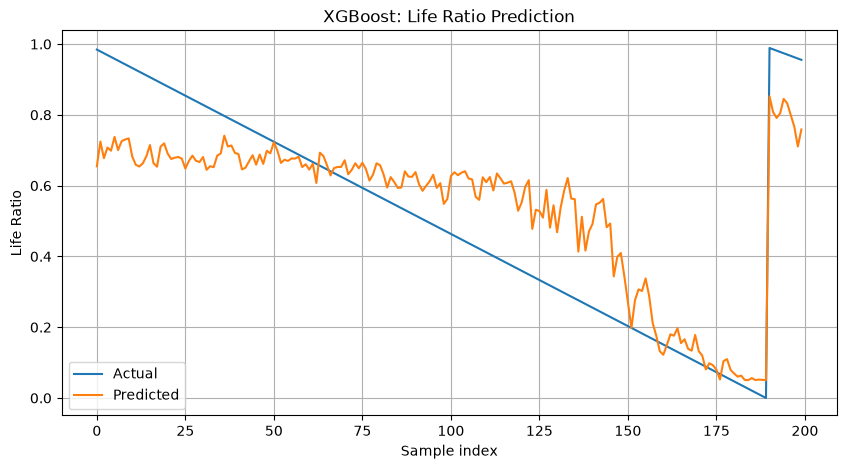

In [36]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("XGBoost: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

## Model comparison table

Validation-set results (target: `life_ratio`, bounded in [0, 1]), comparing this notebook
(no `cycle`) against step3 (with `cycle`):

| Model | Dataset | RMSE (with cycle) | RMSE (no cycle) | R² (with cycle) | R² (no cycle) |
|---|---|---:|---:|---:|---:|
| Random Forest (Optuna-tuned) | Validation | 0.0571 | 0.1771 | 0.9601 | 0.6161 |
| XGBoost (Optuna-tuned) | Validation | 0.0559 | 0.1770 | 0.9617 | 0.6163 |
| XGBoost (Optuna-tuned) | Test | 0.0664 | 0.1845 | 0.9150 | 0.3440 |

Removing `cycle` roughly **triples RMSE** and drags R² down from ~0.96 to ~0.62 on
validation, and from 0.92 to **0.34** on the (harder) test set. XGBoost and Random Forest
perform almost identically to each other without `cycle` (unlike step3, where XGBoost had
a small edge) -- with the dominant feature gone, both models are now limited by the same
thin sensor-only signal rather than by which algorithm is used.

### Interpretable / Explainable predictions using SHAP

In [37]:
import shap

X_sample = X_val.sample(n=10, random_state=42)

explainer = shap.TreeExplainer(best_xg)
shap_values = explainer(X_sample)



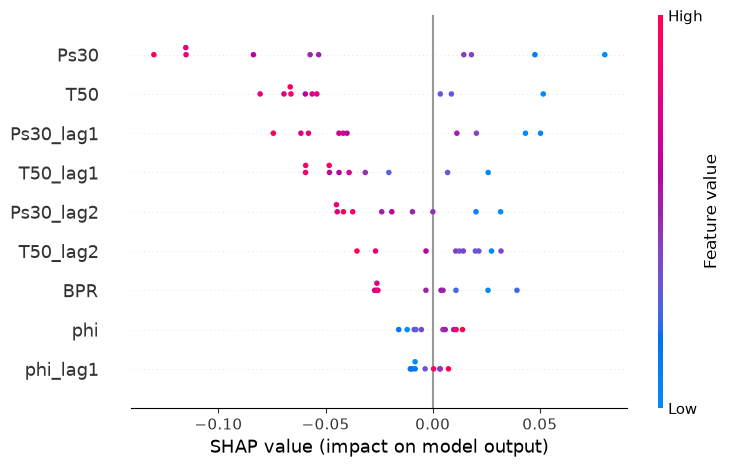

In [38]:
shap.plots.beeswarm(shap_values)

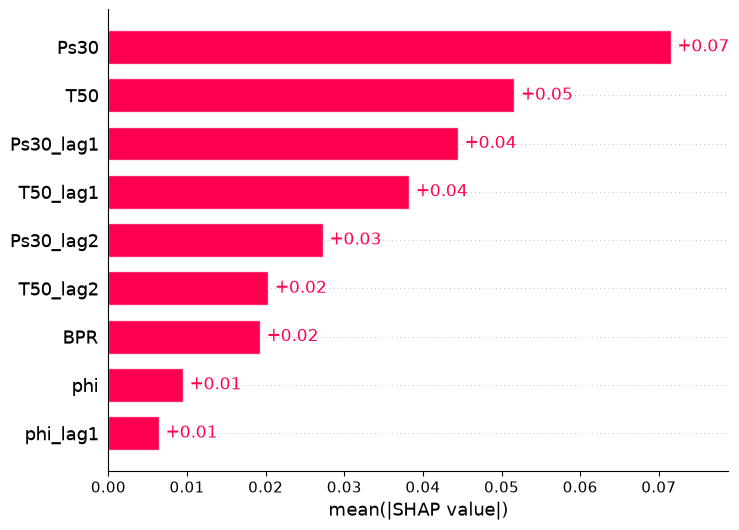

In [39]:
shap.plots.bar(shap_values)

Without `cycle` as a candidate feature, `Ps30` becomes the dominant contributor (mean
|SHAP| ≈ 0.07), followed by `T50` and their lags, then `BPR` and `phi` -- the same features
step3 already flagged as the next-most-important after `cycle`. Note `engine_id` also
occupies one of the 10 "selected" slots here (and in step3): its huge variance inflates its
correlation*variance score despite ~0 real correlation, but it's always dropped before
`X_train`/`X_val` are built, so it never actually reaches the model -- it just wastes a
selection slot that would otherwise go to a 10th real sensor feature.

# Evaluation on test set

In [40]:
import pandas as pd
from src.const import RAW_COLUMN_NAMES

# Read raw test data using the same schema as the training data
columns = RAW_COLUMN_NAMES

# Load the raw test file and the provided RUL values
raw_test = pd.read_csv(
    "../data/raw/test_FD001.txt",
    sep=r"\s+",
    header=None,
    usecols=range(len(columns)),
    names=columns,
    engine="python",
)
raw_rul = pd.read_csv("../data/raw/RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Reconstruct RUL for every observed cycle using the provided terminal RUL values.
# The test set is censored (it doesn't run to failure), so life_ratio can't be
# computed with add_life_ratio() alone -- we need the true total life first.
engine_ids = raw_test["engine_id"].unique()
if len(raw_rul) != len(engine_ids):
    raise ValueError(f"Expected {len(engine_ids)} RUL values, got {len(raw_rul)}")

rul_map = dict(zip(engine_ids, raw_rul.tolist()))
raw_test["rul_at_last_cycle"] = raw_test["engine_id"].map(rul_map)
raw_test["last_cycle"] = raw_test.groupby("engine_id")["cycle"].transform("max")
raw_test["RUL"] = raw_test["rul_at_last_cycle"] + (raw_test["last_cycle"] - raw_test["cycle"])

# Total life = last observed cycle + the RUL still remaining at that cycle
raw_test["total_life"] = raw_test["last_cycle"] + raw_test["rul_at_last_cycle"]
raw_test["life_ratio"] = raw_test["RUL"] / raw_test["total_life"]
raw_test = raw_test.drop(columns=["rul_at_last_cycle", "last_cycle", "RUL", "total_life"])

# Apply the same column drops as training data (skip preprocess(), which assumes
# the dataframe runs to failure -- not true for this censored test set)
raw_test = clean_features(raw_test, cols_to_drop=cols_to_drop)

# Scale using the training-set scaler and create the same engineered features
sensor_cols = get_sensor_columns(raw_test)
raw_test_scaled = raw_test.copy()
raw_test_scaled[sensor_cols] = scaler.transform(raw_test_scaled[sensor_cols])

raw_test_fe = add_time_series_features(raw_test_scaled, sensor_cols)
raw_test_fe = raw_test_fe.dropna().reset_index(drop=True)

# Keep the same feature columns used during model training
raw_test_final = apply_feature_selection(raw_test_fe, selected_features, target="life_ratio")

# Collect processed test data for later evaluation
test_data_processed = [raw_test_final]
test_data_processed = pd.concat(test_data_processed, ignore_index=True)

print("Test preprocessing complete.")
test_data_processed.head()

Test preprocessing complete.


,life_ratio,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR,T50_lag2,cycle
0,0.979021,1,-0.149293,-0.840916,-0.149293,0.752310,-1.501236,-1.278278,1.010825,0.055314,-1.190038,3
1,0.972028,1,-0.977215,-0.274289,-0.149293,-0.050446,-0.840916,-0.149293,0.752310,-1.341760,-1.501236,4
2,0.965035,1,-0.864317,-0.776222,-0.977215,0.997219,-0.274289,-0.149293,-0.050446,-1.037816,-0.840916,5
3,0.958042,1,-1.052481,-1.533583,-0.864317,0.684280,-0.776222,-0.977215,0.997219,-0.485919,-0.274289,6
4,0.951049,1,-0.864317,-0.450523,-1.052481,0.806734,-1.533583,-0.864317,0.684280,-1.349758,-0.776222,7


In [41]:
train_final.columns

Index(['life_ratio', 'engine_id', 'Ps30', 'T50', 'Ps30_lag1', 'phi',
       'T50_lag1', 'Ps30_lag2', 'phi_lag1', 'BPR', 'T50_lag2', 'cycle'],
      dtype='object')

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features and target for evaluation
X_test = test_data_processed.drop(columns=["life_ratio", "engine_id", "cycle"], errors="ignore")
y_test = test_data_processed["life_ratio"]

# Use the trained model from the notebook
if "best_xg" not in globals():
    raise NameError("Train a model first (for example, fit best_xg on X_train/y_train).")

# Predict on the test set
y_pred_test = best_xg.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


Test Performance:
RMSE: 0.1845
MAE : 0.1524
R2  : 0.3440


# Error Analysis

Mean test residual (Actual - Predicted): 0.03931183642058044


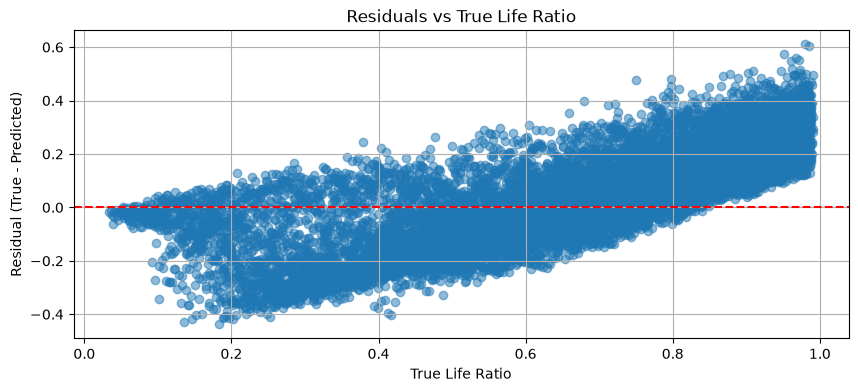

In [43]:
residuals = y_test - y_pred_test
print("Mean test residual (Actual - Predicted):", residuals.mean())

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True Life Ratio")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True Life Ratio")
plt.grid(True)
plt.show()

Without `cycle`, the mean test residual is about **+0.039** (Actual - Predicted, a mild
underprediction on average) -- similar in *sign* to step3's +0.010, but the residual
scatter (above) is dramatically wider: errors of ±0.4-0.6 are common for engines still
early in their life, whereas step3's residuals stayed tightly clustered near 0 across the
whole life_ratio range. The model no longer has a direct signal for "how far along is this
engine," so it can only really trust the sensors once degradation becomes visible.

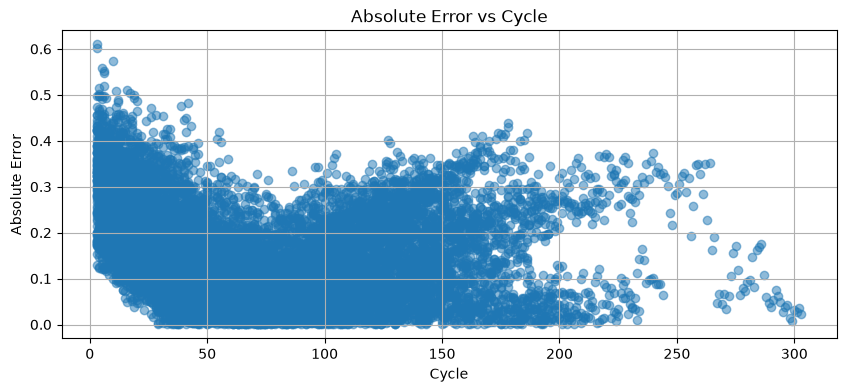

In [44]:
### Error by cycle
plt.figure(figsize=(10, 4))
plt.scatter(test_data_processed["cycle"], np.abs(residuals), alpha=0.5)
plt.xlabel("Cycle")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Cycle")
plt.grid(True)
plt.show()


Error is still lower near failure (high cycle counts) and higher early in an engine's
life, same qualitative pattern as step3 -- but the magnitudes are now much larger overall
(errors up to ~0.6 early on, vs a small fraction of that in step3). Near failure, sensor
degradation is pronounced enough that the model does almost as well without `cycle`; far
from failure, sensors alone carry little signal about remaining life, and `cycle` was
doing most of that work in step3.

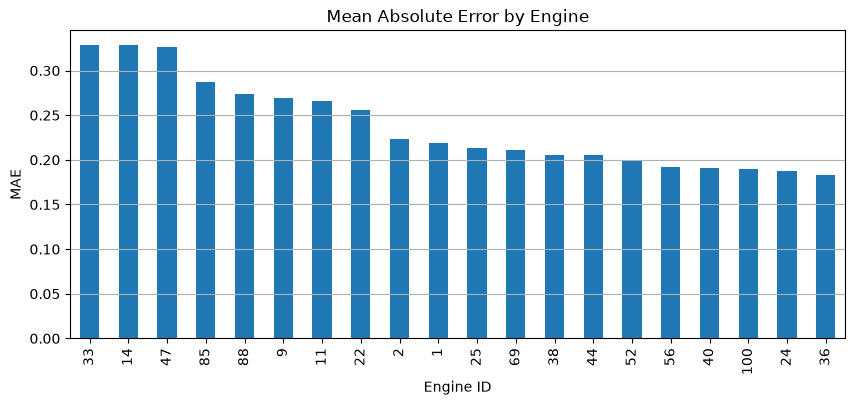

In [45]:
### Error by engine
engine_errors = pd.DataFrame({
    "engine_id": test_data_processed["engine_id"],
    "abs_error": np.abs(residuals)
}).groupby("engine_id")["abs_error"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
engine_errors.head(20).plot(kind="bar")
plt.title("Mean Absolute Error by Engine")
plt.ylabel("MAE")
plt.xlabel("Engine ID")
plt.grid(axis="y")
plt.show()

Engine 33 has the highest errors (MAE ≈ 0.33), versus engine 93 in step3 -- a
different worst engine, consistent with the model now leaning on a different (weaker)
signal.

# Classification Evaluation via binning


When life_ratio is below 0.1 (10% of life remaining), we treat the engine as being in a near-failure state and flag it for maintenance attention. This is often more actionable from a business perspective than reporting a raw life_ratio number, because it supports clear operational decisions such as scheduling inspection, maintenance, or replacement.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

# Note: threshold should not be tuned using test set
def binary_evaluation(threshold=0.1, pred_offset=0.0):
    # Convert continuous life_ratio into a binary class: 1 = near failure, 0 = not near failure
    y_true_bin = (y_test <= threshold).astype(int)
    y_pred_bin = (y_pred_test <= threshold + pred_offset).astype(int)

    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    print("Binary Classification Metrics")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_bin, y_pred_bin, target_names=["Not Near Failure", "Near Failure"]))

    # Optional: plot confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Near Failure", "Near Failure"], yticklabels=["Not Near Failure", "Near Failure"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Near-Failure Classification")
    plt.show()

Binary Classification Metrics
Accuracy : 0.9940
Precision: 0.7439
Recall   : 0.5214
F1-score : 0.6131

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      1.00      1.00     12779
    Near Failure       0.74      0.52      0.61       117

        accuracy                           0.99     12896
       macro avg       0.87      0.76      0.81     12896
    weighted avg       0.99      0.99      0.99     12896



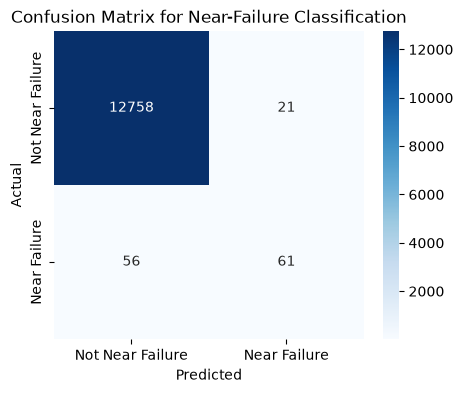

In [47]:
binary_evaluation()

Binary Classification Metrics
Accuracy : 0.9903
Precision: 0.4818
Recall   : 0.9060
F1-score : 0.6291

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      0.99      1.00     12779
    Near Failure       0.48      0.91      0.63       117

        accuracy                           0.99     12896
       macro avg       0.74      0.95      0.81     12896
    weighted avg       0.99      0.99      0.99     12896



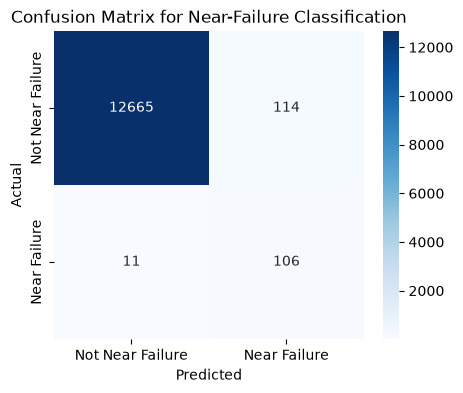

In [48]:
binary_evaluation(pred_offset=0.05)

Because life_ratio is bounded in [0, 1], a prediction offset here is a small ratio
(e.g. 0.05) rather than a cycle count. As before, increasing the offset improves recall
at the cost of precision, letting the business choose the tradeoff between catching more
at-risk engines and tolerating more false alarms. These numbers are close to step3's
(with `cycle`) despite the much worse regression metrics above -- near-failure sensor
degradation alone is nearly enough to flag risk, even without `cycle`.

Example (this notebook, no `cycle`):

Model with offset=0:
- precision = 0.74
- recall = 0.52

Model with offset=0.05:
- precision = 0.48
- recall = 0.91

# Verdict: does the model still perform as well without `cycle`?

**No.** Removing `cycle` as a model input roughly **triples RMSE** and drags R² down
from ~0.96 to ~0.62 on validation, and from 0.92 to **0.34** on the test set (see the
model comparison table above). Optuna tuning barely helps once `cycle` is gone -- the
bottleneck is information, not hyperparameters.

The picture is more nuanced for the **binary near-failure classification** used for
maintenance flagging: precision actually improves slightly (0.69 -> 0.74 at offset=0)
while recall drops (0.70 -> 0.52); F1 stays in the same ballpark (0.70 -> 0.61). Sensor
degradation alone is apparently enough to flag an engine as *near* failure, even without a
cycle counter -- it's *precisely locating* an engine along its full life trajectory (the
continuous life_ratio regression) that needs `cycle`. This also matches the error-by-cycle
plot: error is small near failure in both notebooks, and the gap between them opens up
early/mid-life, exactly where only `cycle` (not yet-visible sensor degradation) told the
original model how much life was left.

**Is this leakage?** No -- `cycle` is a legitimate, always-available feature in
production (it's just an operating-hours counter, not derived from the label in any
illegitimate way), unlike, say, a future sensor reading would be. The model isn't
"cheating"; it's correctly exploiting the strongest legitimate signal available. Given
that, and that removing it causes a large, real accuracy loss with no corresponding
benefit, **the recommendation is to keep `cycle` as a feature** -- the concern that
motivated this notebook (the model "relies too heavily" on it) is true in the sense that
`cycle` dominates SHAP importance, but that reliance is earned, not spurious.

The one caveat: if a production deployment can't guarantee an accurate, consistent
cycle count for every engine (e.g. a reset counter, missing history, a new fleet with no
baseline), this notebook shows what to expect -- a much weaker but not useless model,
still reasonably capable of flagging imminent failure from sensors alone even though its
continuous life-ratio estimates would be far less reliable.

# Verdict: Life ratio vs RUL

Life ratio often produces better RMSE, R², and classification performance in CMAPSS because it normalizes the degradation trajectory into a bounded and monotonic signal. This makes the learning problem easier by reducing target's variance and normalizing to a [0, 1] scale.

## Future work for model improvements

Several next steps could further improve the model and make the results more robust:

- Add a baseline model comparison table, including simple baselines and more advanced models, to better quantify the gain from the current approach.
- Run an ablation study for lag and rolling features to measure how much each feature group contributes to predictive performance.
- Combine multiple datasets or operating conditions to improve generalization and reduce overfitting to a single fleet or regime.
